# Связь прямого и обратного прохода с torch autograd

## Прямой проход

Выход линейного слоя перед активацией задается формулой:

$$ z = w*x + b $$

где
$w$ - это вес, $x$ - это вход, а $b$ - это смещение.

Выход функции активации ReLU задается формулой:

$$ a = max(0, z) $$

Бинарная кросс-энтропийная потеря (loss) задается формулой:

$$ L = -y*log(a) - (1-y)*log(1-a) $$

где $y$ - это разметка.

## Логика обратного прохода

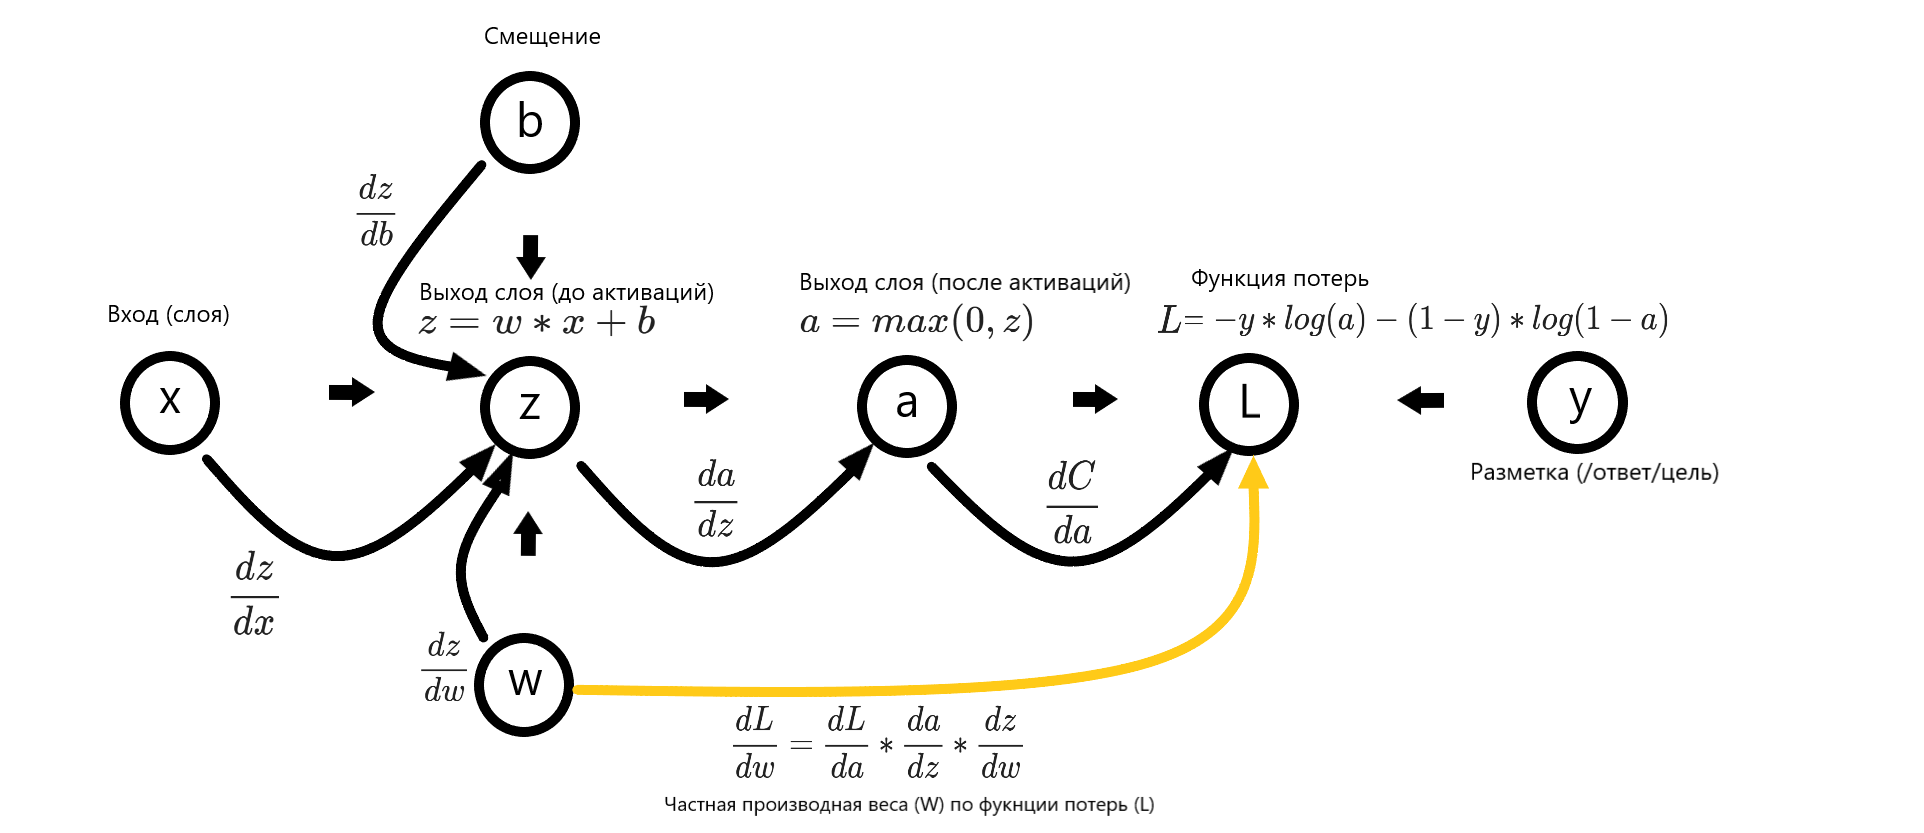

## Вывод обратного прохода

Градиенты потери по отношению к входам, весам и смещению задаются цепным правилом дифференцирования:

$$\frac{dL}{dx} = \frac{dL}{da} * \frac{da}{dz} * \frac{dz}{dx}$$

$$\frac{dL}{dw} = \frac{dL}{da} * \frac{da}{dz} * \frac{dz}{dw}$$

$$\frac{dL}{db} = \frac{dL}{da} * \frac{da}{dz} * \frac{dz}{db}$$

Производная функции активации ReLU:

$$\frac{da}{dz} = \begin{cases}
1 & \text{если } z > 0 \\
0 & \text{иначе}
\end{cases}
$$

Производная бинарной кросс-энтропийной потери:

$$\frac{dL}{da} = -\frac{y}{a} + \frac{1-y}{1-a}
$$

Подставив формулы для промежуточных преобразований получим

$$\frac{dL}{dx} = (-\frac{y}{a} + \frac{1-y}{1-a}) * 1 * w = -\frac{y*w}{a} + \frac{w*(1-y)}{1-a}
$$

$$\frac{dL}{dw} = (-\frac{y}{a} + \frac{1-y}{1-a}) * 1 * x = -\frac{x*y}{a} + \frac{x*(1-y)}{1-a}
$$

$$\frac{dL}{db} = (-\frac{y}{a} + \frac{1-y}{1-a}) * 1 * 1 = -\frac{y}{a} + \frac{1-y}{1-a}
$$

Подставим значения входа, веса, смещения и ответа в эти формулы. Вход $x = 0.5$, вес $w = 1$, смещение $b = 1$, а цель $y = 1$. Выход линейного слоя перед активацией $z = 1.5$, а выход функции активации ReLU $a = 1.5$.

$$\frac{dL}{dx} = -\frac{1*1}{1.5} + \frac{1*(1-1)}{1-1.5} = -\frac{2}{3}$$

$$\frac{dL}{dw} = -\frac{0.5*1}{1.5} + \frac{0.5*(1-1)}{1-1.5} = -\frac{1}{3}$$

$$\frac{dL}{db} = -\frac{1}{1.5} + \frac{1-1}{1-1.5} = -\frac{2}{3}$$

In [ ]:
import torch

# Инициализируем константами
x = torch.tensor([0.5], requires_grad=True)
w = torch.tensor([1.0], requires_grad=True)
b = torch.tensor([1.0], requires_grad=True)
y = torch.tensor([1.0])

# Прямой проход
z = w * x + b
a = torch.relu(z)
# Потери (самописные, чтобы не усложнять S-m)
loss = -(y * torch.log(a) + (1 - y) * torch.log(1 - a))

# Обратный проход
loss.backward()

# Оптимизатор
optimizer = torch.optim.SGD([w, b], lr=1)

# Один шаг
optimizer.step()

# Print the gradients
print("Gradient of x: ", x.grad.item())
print("Gradient of w: ", w.grad.item())
print("Gradient of b: ", b.grad.item())

Gradient of x:  -0.6666666865348816
Gradient of w:  -0.3333333432674408
Gradient of b:  -0.6666666865348816


In [ ]:
w

tensor([1.3333], requires_grad=True)

In [ ]:
b

tensor([1.6667], requires_grad=True)

  0%|          | 0/1000 [00:00<?, ?it/s]

Accuracy: 1.0


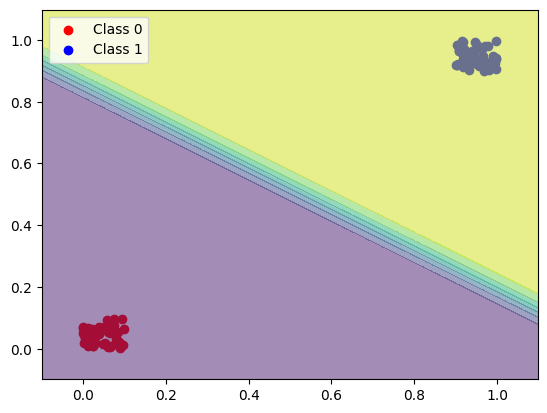

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

# для простоты создаем пл 5 точек вокруг 0, 0 и 1, 1
class0 = torch.rand(50, 2) * 0.1
class1 = torch.rand(50, 2) * 0.1 + 0.9

# создаем разметку из 5 нулей и 5 единиц
features = torch.cat((class0, class1), dim=0)
labels = torch.tensor([0] * 50 + [1] * 50).unsqueeze(1).float()

# создаем загрузчик
dataset = TensorDataset(features, labels)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Step 2: Define the neural network
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.linear1 = nn.Linear(2, 3) # вход 2 признака, скрытый из 3 нейронов
        self.linear2 = nn.Linear(3, 5)
        self.linear3 = nn.Linear(5, 3)
        self.linear4 = nn.Linear(3, 1) # выходной из 3 нейронов и 1 выходом для бинарной се

    def forward(self, x):
        x = self.linear1(x)
        x = torch.relu(x)
        x = self.linear2(x)
        x = torch.relu(x)
        x = self.linear3(x)
        x = torch.relu(x)
        x = self.linear4(x)
        x = torch.sigmoid(x)
        return x

# создаем сеть
model = SimpleNN()

# кросс-экнтропия
criterion = nn.BCELoss()

# оптимизатор
optimizer = optim.Adam(model.parameters(), lr=0.01)

# эпохи
epochs = 1000
model.train()
for epoch in tqdm(range(epochs)):
    for inputs, targets in dataloader:
        # прямой проход
        outputs = model(inputs)

        # расчет лосса
        loss = criterion(outputs, targets)

        # обратный проход
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()


# оценка метрик
def calculate_accuracy(y_true, y_pred):
    predicted_labels = y_pred.round()
    correct = (predicted_labels == y_true).float()
    accuracy = correct.sum() / len(correct)
    return accuracy.item()

model.eval()
with torch.no_grad():
    predictions = model(features)
    accuracy = calculate_accuracy(labels, predictions)
    print(f'Accuracy: {accuracy}')

# валидация
plt.scatter(class0[:, 0], class0[:, 1], color='red', label='Class 0')
plt.scatter(class1[:, 0], class1[:, 1], color='blue', label='Class 1')

# функции для визуализации
x_min, x_max = features[:, 0].min() - 0.1, features[:, 0].max() + 0.1
y_min, y_max = features[:, 1].min() - 0.1, features[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
mesh = torch.Tensor(np.c_[xx.ravel(), yy.ravel()])
with torch.no_grad():
    decision_boundary = model(mesh).reshape(xx.shape)

plt.contourf(xx, yy, decision_boundary, alpha=0.5)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.legend()
plt.show()